In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
from IPython.display import display
import plotly.express as px

# path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
path_local = "/home/scodo/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1/cardio_train.csv"
data = pd.read_csv(path_local, sep=";")
display(data)



\\wsl.localhost\kali-linux\home\scodo\classification_initiation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
print("\n### Valeurs manquantes ###")
missing_values = data.isnull().sum()

if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
    print(f"\nNombre total de lignes avec valeurs manquantes: {data.isnull().any(axis=1).sum()}")

    # Supprimer les lignes avec valeurs manquantes
    data = data.dropna()
    print(f"✓ Lignes avec NaN supprimées. Nouvelle taille: {data.shape}")
else:
    print("Aucune valeur manquante détectée ✓")



### Valeurs manquantes ###
Aucune valeur manquante détectée ✓


In [5]:
# Doublons
print("\n### 3.2 Doublons ###")
duplicates = data.duplicated().sum()
print(f"Nombre de lignes dupliquées: {duplicates}")
if duplicates > 0:
    data = data.drop_duplicates(ignore_index=True)
    print(f"✓ Doublons supprimés. Nouvelle taille: {data.shape}")


### 3.2 Doublons ###
Nombre de lignes dupliquées: 0


In [6]:
# Suppression des colonnes inutiles (IDs)
print("\n### Suppression des colonnes inutiles ###")
columns_to_drop = ['id']

existing_cols_to_drop = [col for col in columns_to_drop if col in data.columns]
print(f"Colonnes à supprimer: {existing_cols_to_drop}")

data = data.drop(columns=existing_cols_to_drop)
print(f"✓ Colonnes supprimées. Nouvelle taille: {data.shape}")



### Suppression des colonnes inutiles ###
Colonnes à supprimer: ['id']
✓ Colonnes supprimées. Nouvelle taille: (70000, 12)


In [7]:
# Statistiques descriptives
print("\n###  Statistiques descriptives ###")
display(data.describe())


###  Statistiques descriptives ###


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
TARGET ='cardio'
QUALITATIVE_VARIABLES = [
    'gender','gluc','smoke','alco','active','cholesterol'
]
QUANTITATIVE_VARIABLES = [col for col in data.columns if col not in QUALITATIVE_VARIABLES + [TARGET]]
QUALITATIVE_VARIABLES = [f for f in QUALITATIVE_VARIABLES if f in data.columns]
data_cat = data[QUALITATIVE_VARIABLES].copy()
data_num = data[QUANTITATIVE_VARIABLES].copy()
data_num


,age,height,weight,ap_hi,ap_lo
0,18393,168,62.0,110,80
1,20228,156,85.0,140,90
2,18857,165,64.0,130,70
3,17623,169,82.0,150,100
4,17474,156,56.0,100,60
...,...,...,...,...,...
69995,19240,168,76.0,120,80
69996,22601,158,126.0,140,90
69997,19066,183,105.0,180,90
69998,22431,163,72.0,135,80


In [9]:
print("="*60)
print("ÉTAPE 4: DÉTECTION DES OUTLIERS")
print("="*60)

# Utiliser la méthode IQR (Interquartile Range)
numeric_cols = data_num.select_dtypes(include=[np.number]).columns

outliers_dict = {}
for col in numeric_cols:
    Q1 = data_num[col].quantile(0.25)
    Q3 = data_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_num[(data[col] < lower_bound) | (data[col] > upper_bound)]
    if len(outliers) > 0:
        outliers_dict[col] = len(outliers)

print("\nNombre d'outliers par colonne:")
if outliers_dict:
    for col, count in sorted(outliers_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"  {col}: {count}")
else:
    print("  Aucun outlier détecté (en utilisant la méthode IQR)")


ÉTAPE 4: DÉTECTION DES OUTLIERS

Nombre d'outliers par colonne:
  ap_lo: 4632
  weight: 1819
  ap_hi: 1435
  height: 519
  age: 4


In [10]:
# === ÉTAPE 5E: VÉRIFICATION DES VALEURS HORS ÉCHELLE ===
print("="*60)
print("ÉTAPE 8C: DÉTECTION DES VALEURS HORS ÉCHELLE")
print("="*60)

print("""
### OBJECTIF ###
Vérifier si certaines valeurs dépassent les limites attendues pour les features Spotify.
Contrairement aux outliers statistiques (IQR), ici on vérifie les limites physiques/logiques.
""")
expected_ranges= {
    'age': (0, 120*365),  # Âge humain plausible
    'height': (50, 250),  # Taille en cm plausible
    'weight': (3, 500),  # Poids en kg plausible
    'ap_hi': (80, 200),  # Pression systolique plausible
    'ap_lo': (60, 120)   # Pression diastolique plausible
}

ÉTAPE 8C: DÉTECTION DES VALEURS HORS ÉCHELLE

### OBJECTIF ###
Vérifier si certaines valeurs dépassent les limites attendues pour les features Spotify.
Contrairement aux outliers statistiques (IQR), ici on vérifie les limites physiques/logiques.



In [11]:
def pression_plausible(sys, dia):

    if sys <= dia:
        return False

    diff = sys - dia

    if diff < 20 or diff > 80:
        return False

    ratio = sys / dia

    if ratio < 1.2 or ratio > 1.8:
        return False

    return True

#ajouter une colonne indiquant si la pression est plausible ou non
data['pression_plausible'] = data.apply(lambda row: pression_plausible(row['ap_hi'], row['ap_lo']), axis=1)
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pression_plausible
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,True
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,True
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,False
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,True
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0,True
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,True
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,False
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1,True


In [12]:
#fonction donnant uniquement les indices des lignes avec des valeurs hors échelle et pression plausible
def detecter_valeurs_hors_echelle(data, expected_ranges):
    indices_hors_echelle = set()

    for col, (min_val, max_val) in expected_ranges.items():
        if col in data.columns:
            hors_echelle = data[(data[col] < min_val) | (data[col] > max_val)].index
            indices_hors_echelle.update(hors_echelle)

    # Vérification de la pression artérielle
    if 'ap_hi' in data.columns and 'ap_lo' in data.columns:
        for idx, row in data.iterrows():
            if not pression_plausible(row['ap_hi'], row['ap_lo']):
                indices_hors_echelle.add(idx)

    return sorted(indices_hors_echelle)

indices_hors_echelle = detecter_valeurs_hors_echelle(data, expected_ranges)
data_hors_echelle = data.loc[indices_hors_echelle]
data_hors_echelle


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pression_plausible
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,False
9,19834,1,164,68.0,110,60,1,1,0,0,0,0,False
16,21296,1,170,75.0,130,70,1,1,0,0,0,0,False
23,23376,2,156,45.0,110,60,1,1,0,0,1,0,False
29,21057,2,169,74.0,130,70,1,3,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69959,19069,1,163,64.0,130,70,1,1,0,0,1,1,False
69967,21416,2,168,63.0,140,1000,1,1,0,0,1,1,False
69992,18792,1,161,56.0,170,90,1,1,0,0,1,1,False
69994,21074,1,165,80.0,150,80,1,1,0,0,1,1,False


In [13]:
# Remplacer ap_hi et ap_lo par les moyennes pour les lignes où pression_plausible est False

# Identifier les lignes avec pression implausible
pression_implausible_mask = ~data['pression_plausible']
nb_lignes_implausible = pression_implausible_mask.sum()

print(f"\nNombre de lignes avec pression implausible: {nb_lignes_implausible}")

if nb_lignes_implausible > 0:
    # Calculer les moyennes
    mean_ap_hi = data[data['pression_plausible']]['ap_hi'].mean()
    mean_ap_lo = data[data['pression_plausible']]['ap_lo'].mean()
    
    print(f"Moyenne de ap_hi (parmi les valeurs plausibles): {mean_ap_hi:.2f}")
    print(f"Moyenne de ap_lo (parmi les valeurs plausibles): {mean_ap_lo:.2f}")
    
    # Arrondir les moyennes pour les assigner aux colonnes int64
    mean_ap_hi_rounded = int(round(mean_ap_hi))
    mean_ap_lo_rounded = int(round(mean_ap_lo))
    
    print(f"Valeurs arrondies: ap_hi={mean_ap_hi_rounded}, ap_lo={mean_ap_lo_rounded}")
    
    # Remplacer les valeurs
    data.loc[pression_implausible_mask, 'ap_hi'] = mean_ap_hi_rounded
    data.loc[pression_implausible_mask, 'ap_lo'] = mean_ap_lo_rounded
    
    print(f"\n✓ {nb_lignes_implausible} lignes ont été corrigées")
    print("\nAperçu des lignes corrigées:")
    display(data[pression_implausible_mask][['age', 'ap_hi', 'ap_lo', 'pression_plausible']].head())
else:
    print("Aucune ligne avec pression implausible à corriger")


Nombre de lignes avec pression implausible: 5416
Moyenne de ap_hi (parmi les valeurs plausibles): 125.67
Moyenne de ap_lo (parmi les valeurs plausibles): 81.78
Valeurs arrondies: ap_hi=126, ap_lo=82

✓ 5416 lignes ont été corrigées

Aperçu des lignes corrigées:


,age,ap_hi,ap_lo,pression_plausible
2,18857,126,82,False
9,19834,126,82,False
16,21296,126,82,False
23,23376,126,82,False
29,21057,126,82,False


In [14]:
# Préparer les données pour la modélisation
print("="*60)
print("ÉTAPE 9: PRÉPARATION POUR LA MODÉLISATION")
print("="*60)

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Séparer features et target
y = data[TARGET]
X = data.drop(columns=[TARGET, 'pression_plausible'])

print(f"\nShape des données:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"\nDistribution de la cible:")
print(y.value_counts())

ÉTAPE 9: PRÉPARATION POUR LA MODÉLISATION

Shape des données:
X: (70000, 11)
y: (70000,)

Distribution de la cible:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [15]:
# Diviser et normaliser les données
print("="*60)
print("DIVISION TRAIN/TEST ET NORMALISATION")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\nDivision train/test: {X_train.shape[0]}/{X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"\nNormalisation effectuée avec StandardScaler")

DIVISION TRAIN/TEST ET NORMALISATION

Division train/test: 56000/14000
Features: 11

Normalisation effectuée avec StandardScaler


In [16]:
# Entraîner différents modèles en boucle avec cross-validation
print("="*60)
print("ENTRAÎNEMENT DES MODÈLES AVEC CROSS-VALIDATION")
print("="*60)

# Définir les modèles
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'scaled': True
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'scaled': False
    }
}

# Stockage des résultats
results = {}
trained_models = {}

# Boucle d'entraînement
for model_name, config in models.items():
    print(f"\n--- {model_name} ---")
    
    # Choisir les données appropriées
    X_train_data = X_train_scaled if config['scaled'] else X_train
    X_test_data = X_test_scaled if config['scaled'] else X_test
    
    # Cross-validation
    cv_scores = cross_validate(
        config['model'], X_train_data, y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    # Entraîner sur l'ensemble train
    config['model'].fit(X_train_data, y_train)
    
    # Prédictions
    y_pred = config['model'].predict(X_test_data)
    y_pred_proba = config['model'].predict_proba(X_test_data)[:, 1]
    
    # Métriques de test
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Stocker les résultats
    results[model_name] = {
        'cv_accuracy': cv_scores['test_accuracy'].mean(),
        'cv_accuracy_std': cv_scores['test_accuracy'].std(),
        'cv_f1': cv_scores['test_f1'].mean(),
        'cv_f1_std': cv_scores['test_f1'].std(),
        'cv_roc_auc': cv_scores['test_roc_auc'].mean(),
        'cv_roc_auc_std': cv_scores['test_roc_auc'].std(),
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    trained_models[model_name] = {
        'model': config['model'],
        'scaled': config['scaled']
    }
    
    # Affichage
    print(f"CV Accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
    print(f"CV F1-Score: {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
    print(f"CV ROC-AUC:  {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test F1:       {test_f1:.4f}")
    print(f"Test ROC-AUC:  {test_roc_auc:.4f}")

print("\n" + "="*60)
print("✓ Entraînement terminé pour tous les modèles")
print("="*60)

ENTRAÎNEMENT DES MODÈLES AVEC CROSS-VALIDATION

--- Logistic Regression ---
CV Accuracy: 0.7210 (+/- 0.0053)
CV F1-Score: 0.7069 (+/- 0.0056)
CV ROC-AUC:  0.7853 (+/- 0.0065)
Test Accuracy: 0.7145
Test F1:       0.7016
Test ROC-AUC:  0.7803

--- Random Forest ---
CV Accuracy: 0.7080 (+/- 0.0048)
CV F1-Score: 0.7054 (+/- 0.0043)
CV ROC-AUC:  0.7683 (+/- 0.0059)
Test Accuracy: 0.7039
Test F1:       0.7025
Test ROC-AUC:  0.7623

--- Gradient Boosting ---
CV Accuracy: 0.7299 (+/- 0.0055)
CV F1-Score: 0.7244 (+/- 0.0059)
CV ROC-AUC:  0.7969 (+/- 0.0061)
Test Accuracy: 0.7247
Test F1:       0.7208
Test ROC-AUC:  0.7920

✓ Entraînement terminé pour tous les modèles


In [17]:
# Créer un tableau comparatif des performances
print("="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'CV Accuracy': [results[m]['cv_accuracy'] for m in results.keys()],
    'CV F1': [results[m]['cv_f1'] for m in results.keys()],
    'CV ROC-AUC': [results[m]['cv_roc_auc'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Test F1': [results[m]['test_f1'] for m in results.keys()],
    'Test ROC-AUC': [results[m]['test_roc_auc'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test ROC-AUC', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# Sélectionner le meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
best_model_roc_auc = comparison_df.iloc[0]['Test ROC-AUC']

print("\n" + "="*60)
print(f"🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   Test ROC-AUC: {best_model_roc_auc:.4f}")
print("="*60)

# Stocker le meilleur modèle
best_model = trained_models[best_model_name]['model']
best_model_scaled = trained_models[best_model_name]['scaled']
best_model_data = results[best_model_name]

COMPARAISON DES MODÈLES

             Modèle  CV Accuracy    CV F1  CV ROC-AUC  Test Accuracy  Test F1  Test ROC-AUC
  Gradient Boosting     0.729946 0.724394    0.796854       0.724714 0.720846      0.791990
Logistic Regression     0.721018 0.706936    0.785289       0.714500 0.701605      0.780311
      Random Forest     0.708036 0.705444    0.768259       0.703857 0.702454      0.762271

🏆 MEILLEUR MODÈLE: Gradient Boosting
   Test ROC-AUC: 0.7920


In [19]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl (73 kB)
Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


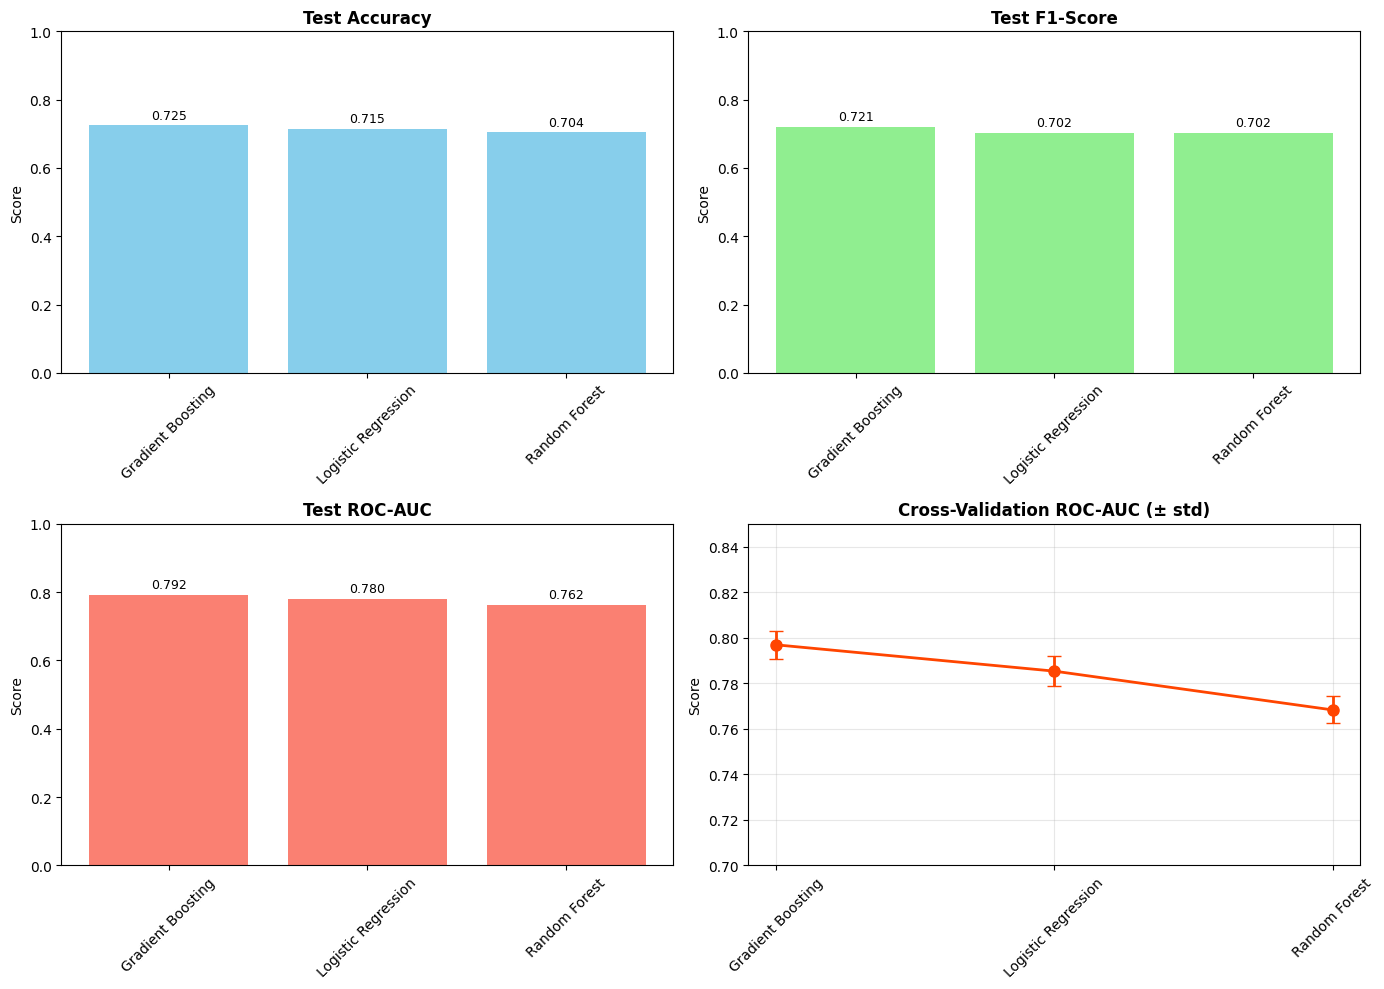

✓ Visualizations affichées


In [20]:
# Visualiser les performances des modèles
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(comparison_df['Modèle'], comparison_df['Test Accuracy'], color='skyblue')
axes[0, 0].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# F1-Score
axes[0, 1].bar(comparison_df['Modèle'], comparison_df['Test F1'], color='lightgreen')
axes[0, 1].set_title('Test F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test F1']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# ROC-AUC
axes[1, 0].bar(comparison_df['Modèle'], comparison_df['Test ROC-AUC'], color='salmon')
axes[1, 0].set_title('Test ROC-AUC', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test ROC-AUC']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# CV ROC-AUC avec erreurs
axes[1, 1].errorbar(
    range(len(comparison_df)), 
    comparison_df['CV ROC-AUC'], 
    yerr=[results[m]['cv_roc_auc_std'] for m in comparison_df['Modèle']],
    fmt='o-', color='orangered', capsize=5, markersize=8, linewidth=2
)
axes[1, 1].set_title('Cross-Validation ROC-AUC (± std)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0.7, 0.85)
axes[1, 1].set_xticks(range(len(comparison_df)))
axes[1, 1].set_xticklabels(comparison_df['Modèle'], rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations affichées")

ANALYSE DÉTAILLÉE - Gradient Boosting

Matrice de Confusion:
[[5170 1834]
 [2020 4976]]

Rapport de Classification:
                precision    recall  f1-score   support

Pas Malade (0)       0.72      0.74      0.73      7004
    Malade (1)       0.73      0.71      0.72      6996

      accuracy                           0.72     14000
     macro avg       0.72      0.72      0.72     14000
  weighted avg       0.72      0.72      0.72     14000



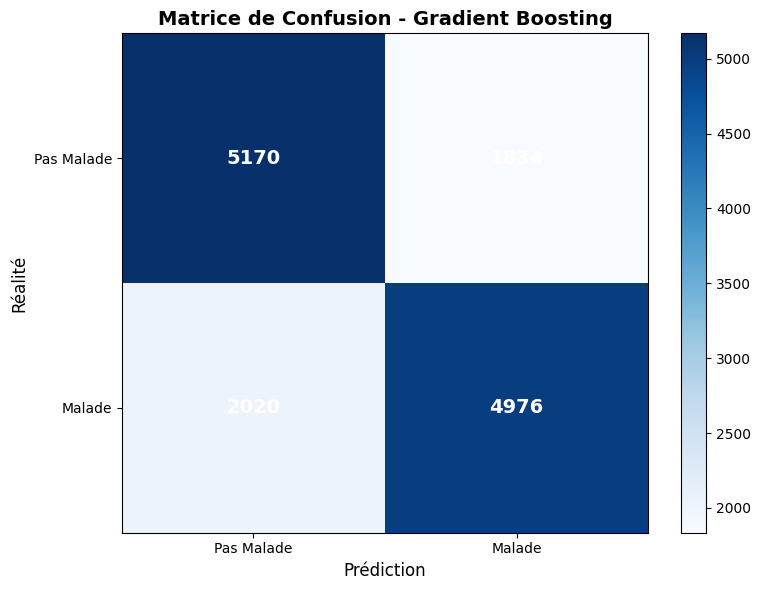


✓ Matrice de confusion affichée


In [21]:
# Analyser le meilleur modèle en détail
print("="*60)
print(f"ANALYSE DÉTAILLÉE - {best_model_name}")
print("="*60)

# Matrice de confusion
cm = confusion_matrix(y_test, best_model_data['y_pred'])

print("\nMatrice de Confusion:")
print(cm)

# Rapport de classification
print(f"\nRapport de Classification:")
print(classification_report(y_test, best_model_data['y_pred'], 
                          target_names=['Pas Malade (0)', 'Malade (1)']))

# Visualiser la matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Réalité', fontsize=12)
ax.set_title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pas Malade', 'Malade'])
ax.set_yticklabels(['Pas Malade', 'Malade'])

# Ajouter les valeurs
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="white", fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\n✓ Matrice de confusion affichée")

COURBES ROC - COMPARAISON DE TOUS LES MODÈLES


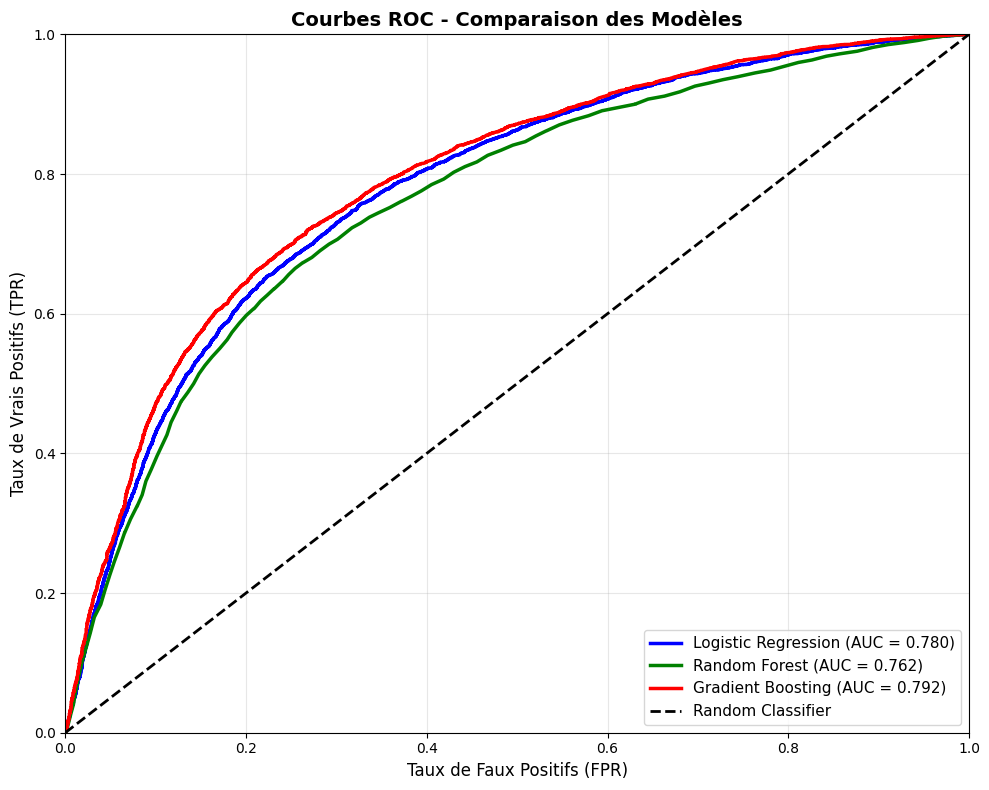


✓ Courbes ROC affichées


In [22]:
# Tracer les courbes ROC pour tous les modèles
from sklearn.metrics import roc_curve, auc

print("="*60)
print("COURBES ROC - COMPARAISON DE TOUS LES MODÈLES")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'orange']

for i, (model_name, result) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', 
            linewidth=2.5, color=colors[i])

# Ligne de base (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ Courbes ROC affichées")

IMPORTANCE DES FEATURES - Gradient Boosting

Top 10 Features:
    Feature  Importance
      ap_hi    0.702796
        age    0.139186
cholesterol    0.080799
      ap_lo    0.037786
     weight    0.022308
       gluc    0.004476
     active    0.004167
     height    0.003711
      smoke    0.002190
       alco    0.001415


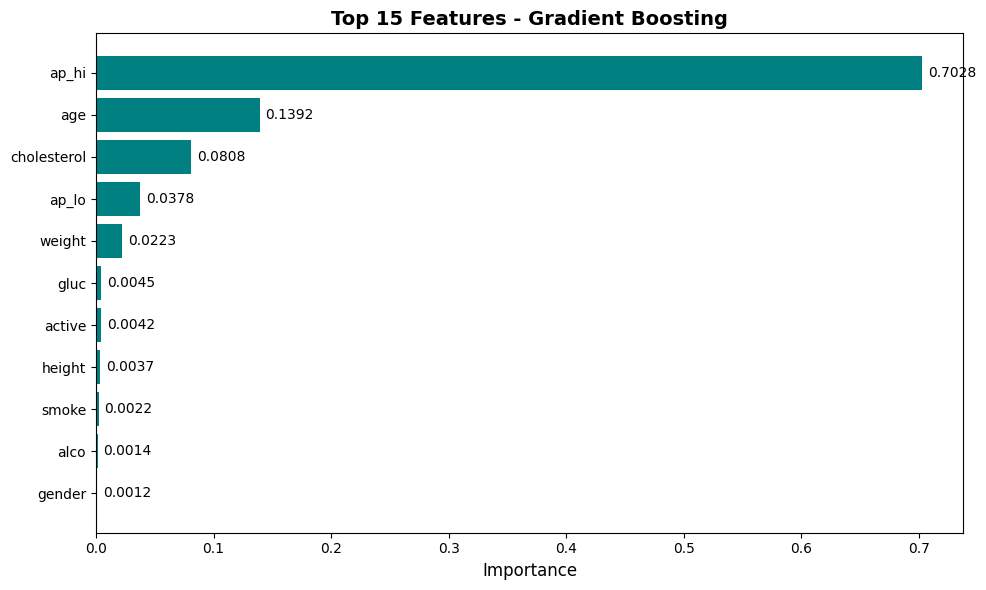


✓ Importance des features affichée


In [23]:
# Afficher l'importance des features du meilleur modèle
print("="*60)
print(f"IMPORTANCE DES FEATURES - {best_model_name}")
print("="*60)

# Vérifier si le modèle a l'attribut feature_importances_
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Visualiser
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance.head(15)
    ax.barh(range(len(top_features)), top_features['Importance'], color='teal')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, v in enumerate(top_features['Importance']):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Importance des features affichée")
else:
    print(f"\n⚠ {best_model_name} ne dispose pas d'un attribut 'feature_importances_'")
    
    # Pour logistic regression, afficher les coefficients
    if hasattr(best_model, 'coef_'):
        coef_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Coefficient': best_model.coef_[0]
        }).reindex(pd.DataFrame({
            'Feature': X_train.columns,
            'Abs_Coefficient': np.abs(best_model.coef_[0])
        }).sort_values('Abs_Coefficient', ascending=False)['Feature'])
        
        print("\nTop 10 Features (par valeur absolue du coefficient):")
        print(coef_importance.head(10).to_string(index=False))